# LAB 1 — Notebook 04: Anomaly Detection Paradigm
## Mobile Money Fraud Detection | EEF606 | University of Buea

---
**Prerequisite:** Run `lab1_00_eda_analysis.ipynb` first.

### What is Anomaly Detection?
Anomaly detection asks: **'Does this transaction look DIFFERENT from normal behaviour?'**

Key distinction from classification:
- **Classification** requires labelled fraud examples to learn from
- **Anomaly Detection** only needs to learn what NORMAL looks like — then anything far from normal is suspicious

This is powerful in fraud because:
- New fraud patterns emerge constantly — labelled examples may not exist yet
- In early deployment, you may have zero confirmed fraud labels
- Fraudsters adapt — anomaly detection catches novel attack methods

### Algorithms tested:
| Algorithm | Core Idea |
|-----------|----------|
| Isolation Forest | Anomalies are easier to isolate (shorter tree paths) |
| Local Outlier Factor | Anomalies have lower density than their neighbours |
| One-Class SVM | Learns a boundary around normal data |
| Elliptic Envelope | Assumes normal data is Gaussian, flags outliers |
| Statistical (Z-score) | Points > N standard deviations from mean |
| IQR Method | Points outside Q1-1.5×IQR or Q3+1.5×IQR |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# WHY sklearn.covariance.EllipticEnvelope:
# Fits a multivariate Gaussian to the data. Any point
# whose Mahalanobis distance exceeds the contamination
# threshold is flagged. Mahalanobis distance accounts for
# feature correlations, unlike Euclidean distance.
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection     import train_test_split
from sklearn.preprocessing       import RobustScaler
from sklearn.ensemble            import IsolationForest
from sklearn.neighbors           import LocalOutlierFactor
from sklearn.svm                 import OneClassSVM
from sklearn.covariance          import EllipticEnvelope
from sklearn.decomposition       import PCA
from sklearn.metrics             import (classification_report, confusion_matrix,
                                          roc_auc_score, average_precision_score,
                                          f1_score, ConfusionMatrixDisplay)

plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.facecolor':'#F8F9FA','axes.grid':True,'grid.alpha':0.4})
SEED = 42
C_LEGIT = '#2196F3'
C_FRAUD = '#F44336'
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data
#
# WHY contamination=fraud_rate MATTERS:
# Unsupervised anomaly detectors need to be told:
# 'approximately what fraction of data is anomalous?'
# This is called the CONTAMINATION parameter.
# Setting it too low → misses fraud.
# Setting it too high → too many false alarms.
# We use the true fraud rate from our EDA.
# ══════════════════════════════════════════════════════════
df = pd.read_csv('paysim_features.csv')
df = df.drop(columns=[c for c in ['isFlaggedFraud'] if c in df.columns])

X = df.drop(columns=['isFraud'])
y = df['isFraud']

fraud_rate = y.mean()
print(f'Fraud rate (contamination): {fraud_rate:.4f} ({fraud_rate*100:.2f}%)')

# For anomaly detection: train ONLY on legitimate transactions
# WHY: We teach the model what NORMAL looks like.
# It has never seen fraud — anything unusual gets flagged.
X_legit = X[y == 0]
X_fraud  = X[y == 1]
print(f'Legitimate transactions: {len(X_legit):,}')
print(f'Fraud transactions:      {len(X_fraud):,}')

scaler = RobustScaler()
X_legit_sc = scaler.fit_transform(X_legit)  # scale on legit only — this is 'normal'
X_all_sc   = scaler.transform(X)             # same scale for evaluation

# Anomaly detection convention: -1 = anomaly, 1 = normal
# We need to convert our y (0=legit, 1=fraud) to this convention
y_ad = np.where(y == 1, -1, 1)  # fraud → -1, legit → +1

Fraud rate (contamination): 0.0006 (0.06%)
Legitimate transactions: 299,819
Fraud transactions:      181


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Isolation Forest
#
# HOW IT WORKS:
# Build many random decision trees. To 'isolate' a point,
# the tree splits features randomly until the point is alone.
# Anomalies are isolated in FEWER splits (shorter path length)
# because they're in sparse regions of the feature space.
# Normal points require many splits to isolate.
#
# The anomaly score = average path length across all trees.
# Short path = likely anomaly. Long path = likely normal.
#
# WHY n_estimators=200:
# More trees = more stable scores. 100 can be noisy for
# small fraud populations. 200 balances speed and stability.
# ══════════════════════════════════════════════════════════
print('Training Isolation Forest ...')
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=SEED,
    n_jobs=-1
)
iso_forest.fit(X_legit_sc)  # train ONLY on legitimate data

# Predict on ALL data
iso_preds  = iso_forest.predict(X_all_sc)          # -1 or +1
iso_scores = -iso_forest.score_samples(X_all_sc)   # higher = more anomalous

# Convert -1/+1 back to 0/1 for sklearn metrics
iso_labels = np.where(iso_preds == -1, 1, 0)

print(f'Flagged as anomaly: {(iso_preds==-1).sum():,} transactions')
print(f'F1-Score (Fraud):   {f1_score(y, iso_labels, zero_division=0):.4f}')
print(f'PR-AUC:             {average_precision_score(y, iso_scores):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y, iso_scores):.4f}')

Training Isolation Forest ...
Flagged as anomaly: 182 transactions
F1-Score (Fraud):   0.0055
PR-AUC:             0.0071
ROC-AUC:            0.9184


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Local Outlier Factor (LOF)
#
# HOW IT WORKS:
# Compares the LOCAL density of a point to its neighbours.
# If a point's neighbourhood is sparse compared to its
# neighbours' neighbourhoods → it's an outlier.
#
# Intuition: imagine a fraud transaction in the middle of
# an empty region of feature space. Its k nearest neighbours
# are far away. Their own neighbourhoods are denser.
# LOF = ratio of neighbour density to point density.
# LOF >> 1 = outlier/anomaly.
#
# WHY novelty=True:
# By default LOF only predicts on training data (transductive).
# novelty=True allows predicting on NEW data (inductive).
# ══════════════════════════════════════════════════════════
print('Training Local Outlier Factor (subsampled for speed) ...')

# LOF becomes extremely slow above a few thousand samples
n_lof = min(20000, len(X_legit_sc))

rng = np.random.default_rng(SEED)
idx_lof = rng.choice(len(X_legit_sc), n_lof, replace=False)

X_legit_lof = X_legit_sc[idx_lof]

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=fraud_rate,
    novelty=True,
    n_jobs=-1
)

lof.fit(X_legit_lof)

lof_preds  = lof.predict(X_all_sc)
lof_scores = -lof.score_samples(X_all_sc)
lof_labels = np.where(lof_preds == -1, 1, 0)

print(f'Flagged as anomaly: {(lof_preds==-1).sum():,}')
print(f'F1-Score (Fraud):   {f1_score(y, lof_labels, zero_division=0):.4f}')
print(f'PR-AUC:             {average_precision_score(y, lof_scores):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y, lof_scores):.4f}')

Training Local Outlier Factor (subsampled for speed) ...
Flagged as anomaly: 234
F1-Score (Fraud):   0.0530
PR-AUC:             0.0307
ROC-AUC:            0.9291


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 5 — One-Class SVM
#
# HOW IT WORKS:
# Learns a decision boundary (hyperplane in kernel space)
# that encloses the NORMAL data with maximum margin.
# Anything outside this boundary = anomaly.
#
# WHY nu PARAMETER:
# nu = upper bound on fraction of outliers in training.
# nu = fraud_rate means: 'at most this many training
# samples can be on the wrong side of the boundary'.
#
# LIMITATION: One-Class SVM is SLOW on large datasets.
# We subsample legit data for training speed.
# ══════════════════════════════════════════════════════════
print('Training One-Class SVM (subsampled for speed) ...')
# Subsample legitimate data — OC-SVM is O(n²)
n_sample = min(3000, len(X_legit_sc))
idx_sample = np.random.default_rng(SEED).choice(len(X_legit_sc), n_sample, replace=False)
X_legit_sample = X_legit_sc[idx_sample]

oc_svm = OneClassSVM(
    kernel='rbf',
    nu=min(fraud_rate * 2, 0.5),  # slightly generous
    gamma='scale'
)
oc_svm.fit(X_legit_sample)

ocsvm_preds  = oc_svm.predict(X_all_sc)
ocsvm_scores = -oc_svm.score_samples(X_all_sc)
ocsvm_labels = np.where(ocsvm_preds == -1, 1, 0)

print(f'Flagged as anomaly: {(ocsvm_preds==-1).sum():,}')
print(f'F1-Score (Fraud):   {f1_score(y, ocsvm_labels, zero_division=0):.4f}')
print(f'PR-AUC:             {average_precision_score(y, ocsvm_scores):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y, ocsvm_scores):.4f}')

Training One-Class SVM (subsampled for speed) ...
Flagged as anomaly: 5,283
F1-Score (Fraud):   0.0073
PR-AUC:             0.0029
ROC-AUC:            0.6117


In [7]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Elliptic Envelope
#
# HOW IT WORKS:
# Assumes normal data follows a multivariate Gaussian
# distribution (ellipse shape in feature space).
# Estimates the mean and covariance of normal transactions,
# then flags points whose Mahalanobis distance from the
# centre exceeds a threshold.
#
# STRENGTH: Very fast, interpretable.
# WEAKNESS: Assumes Gaussian distribution — fails if
# normal data is multi-modal or skewed.
# ══════════════════════════════════════════════════════════
print('Training Elliptic Envelope ...')

# Use only top features (Elliptic Envelope needs well-conditioned covariance)
top_features = ['log_amount','orig_account_drained','dest_was_empty',
                'error_balance_orig','is_high_risk_type','amount_to_balance_ratio']
top_features = [f for f in top_features if f in X.columns]
if len(top_features) < 3:
    top_features = X.columns[:6].tolist()

X_sub = scaler.fit_transform(X[top_features])
X_sub_legit = X_sub[y==0]

ee = EllipticEnvelope(contamination=fraud_rate, random_state=SEED)
ee.fit(X_sub_legit)

ee_preds  = ee.predict(X_sub)
ee_scores = -ee.score_samples(X_sub)
ee_labels = np.where(ee_preds == -1, 1, 0)

print(f'Flagged as anomaly: {(ee_preds==-1).sum():,}')
print(f'F1-Score (Fraud):   {f1_score(y, ee_labels, zero_division=0):.4f}')
print(f'PR-AUC:             {average_precision_score(y, ee_scores):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y, ee_scores):.4f}')

Training Elliptic Envelope ...
Flagged as anomaly: 181
F1-Score (Fraud):   0.0000
PR-AUC:             0.0008
ROC-AUC:            0.6033


In [8]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Statistical Baselines (Z-Score + IQR)
#
# WHY INCLUDE STATISTICAL METHODS:
# These are the SIMPLEST anomaly detectors. They require
# no training, no parameters, and are fully interpretable.
# Every ML model should be compared against them.
# If your ML model can't beat a Z-score check, something is wrong.
#
# Z-SCORE: flag if any feature is > N standard deviations from mean.
# A transaction at z=5 on 'amount' is 5 std above average — very unusual.
#
# IQR: flag if any feature is outside [Q1-1.5*IQR, Q3+1.5*IQR].
# Same as the box plot whiskers. More robust than z-score for skewed data.
# ══════════════════════════════════════════════════════════
print('Statistical Anomaly Detection Baselines ...')

# Z-Score method (on all features)
X_std = (X_all_sc - X_all_sc.mean(axis=0)) / (X_all_sc.std(axis=0) + 1e-8)
z_scores      = np.abs(X_std).max(axis=1)    # max z across all features per transaction
z_threshold   = np.percentile(z_scores, (1-fraud_rate)*100)  # top fraud_rate% = anomaly
z_labels      = (z_scores >= z_threshold).astype(int)

# IQR method
Q1  = np.percentile(X_all_sc, 25, axis=0)
Q3  = np.percentile(X_all_sc, 75, axis=0)
IQR = Q3 - Q1
iqr_outlier   = ((X_all_sc < Q1 - 1.5*IQR) | (X_all_sc > Q3 + 1.5*IQR)).any(axis=1)
iqr_labels    = iqr_outlier.astype(int)

for name, preds, scores in [
    ('Z-Score',  z_labels,   z_scores),
    ('IQR',      iqr_labels, z_scores),   # use z_scores as proxy for IQR ordering
]:
    print(f'{name}:')
    print(f'  Flagged: {preds.sum():,}  |  '
          f'F1={f1_score(y, preds, zero_division=0):.4f}  |  '
          f'PR-AUC={average_precision_score(y, scores):.4f}')

Statistical Anomaly Detection Baselines ...
Z-Score:
  Flagged: 181  |  F1=0.0331  |  PR-AUC=0.0044
IQR:
  Flagged: 196,619  |  F1=0.0018  |  PR-AUC=0.0044


PCA Reconstruction Error Anomaly Detection ...
PCA components retained: 2 (explains 95% of legit variance)
Flagged as anomaly: 183
F1-Score (Fraud):   0.0110
PR-AUC:             0.0026
ROC-AUC:            0.7867


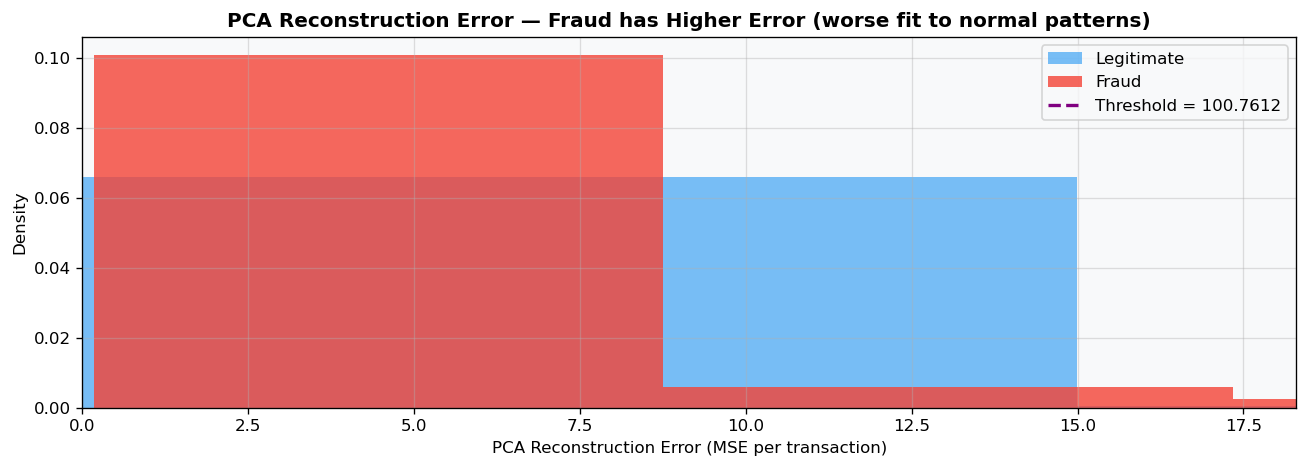

In [9]:
# ══════════════════════════════════════════════════════════
# CELL 8 — PCA Reconstruction Error
#
# HOW IT WORKS:
# PCA learns the principal directions of NORMAL data variation.
# When a fraudulent transaction is projected onto these
# directions, the reconstruction is POOR because fraud
# patterns don't align with normal variation.
# Reconstruction error = how much information is lost in PCA.
# High reconstruction error = anomaly.
#
# WHY n_components=0.95:
# Keep enough components to explain 95% of variance in
# normal data. Remaining 5% is noise — fraud patterns
# live in this 'noise' space and are lost in reconstruction.
# ══════════════════════════════════════════════════════════
print('PCA Reconstruction Error Anomaly Detection ...')

pca = PCA(n_components=0.95, random_state=SEED)
pca.fit(X_legit_sc)

X_reduced      = pca.transform(X_all_sc)
X_reconstructed = pca.inverse_transform(X_reduced)
recon_errors   = np.mean((X_all_sc - X_reconstructed)**2, axis=1)  # MSE per transaction

pca_threshold  = np.percentile(recon_errors[y==0], (1-fraud_rate)*100)
pca_labels     = (recon_errors >= pca_threshold).astype(int)

print(f'PCA components retained: {pca.n_components_} (explains 95% of legit variance)')
print(f'Flagged as anomaly: {pca_labels.sum():,}')
print(f'F1-Score (Fraud):   {f1_score(y, pca_labels, zero_division=0):.4f}')
print(f'PR-AUC:             {average_precision_score(y, recon_errors):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y, recon_errors):.4f}')

# Visualise reconstruction error distribution
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(recon_errors[y==0], bins=80, color=C_LEGIT, alpha=0.6, label='Legitimate', density=True)
ax.hist(recon_errors[y==1], bins=30, color=C_FRAUD, alpha=0.8, label='Fraud', density=True)
ax.axvline(pca_threshold, color='purple', linewidth=2, linestyle='--',
           label=f'Threshold = {pca_threshold:.4f}')
ax.set_xlabel('PCA Reconstruction Error (MSE per transaction)')
ax.set_ylabel('Density')
ax.set_title('PCA Reconstruction Error — Fraud has Higher Error (worse fit to normal patterns)',
             fontweight='bold')
ax.legend()
ax.set_xlim([0, np.percentile(recon_errors, 99)])
plt.tight_layout()
plt.savefig('fig_anom_01_pca_recon_error.png', bbox_inches='tight')
plt.show()

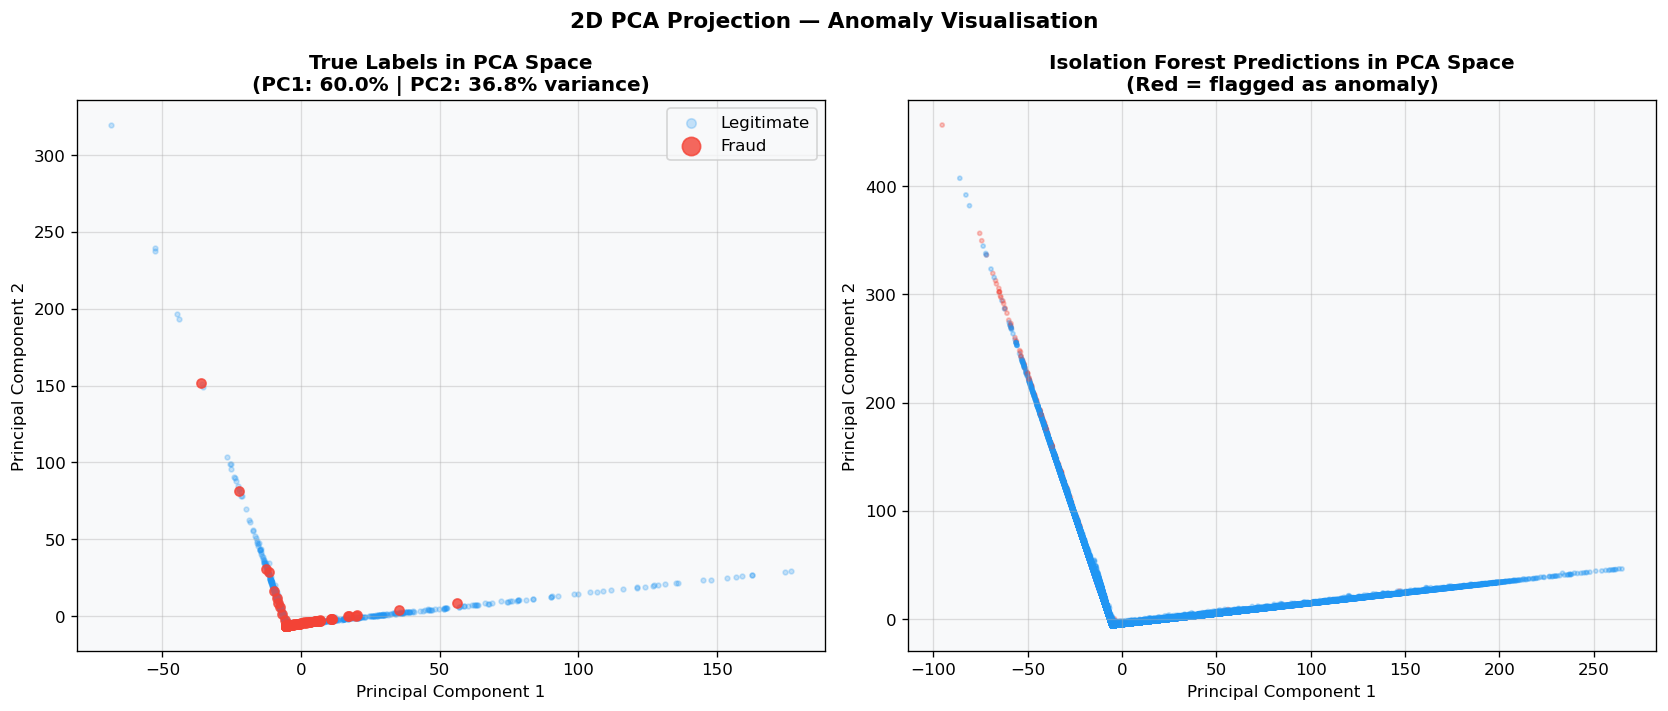

In [10]:
# ══════════════════════════════════════════════════════════
# CELL 9 — 2D PCA Visualisation of Anomalies
#
# WHY VISUALISE IN 2D:
# Our feature space has 15+ dimensions — impossible to visualise.
# PCA projects to 2D while preserving maximum variance.
# This lets us SEE whether fraud clusters separately from
# legitimate transactions in feature space.
# If they completely overlap → hard problem.
# If they separate → our features are doing their job.
# ══════════════════════════════════════════════════════════
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(X_all_sc)

# Sample for readability
rng = np.random.default_rng(SEED)
n_show_legit = min(2000, (y==0).sum())
n_show_fraud = (y==1).sum()
idx_legit = rng.choice(np.where(y==0)[0], n_show_legit, replace=False)
idx_fraud = np.where(y==1)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True labels
axes[0].scatter(X_2d[idx_legit, 0], X_2d[idx_legit, 1],
                c=C_LEGIT, alpha=0.25, s=8, label='Legitimate')
axes[0].scatter(X_2d[idx_fraud, 0], X_2d[idx_fraud, 1],
                c=C_FRAUD, alpha=0.8, s=30, label='Fraud', zorder=5)
axes[0].set_title(f'True Labels in PCA Space\n'
                  f'(PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}% | '
                  f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)',
                  fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(markerscale=2)

# Isolation Forest predictions
pred_colors = [C_FRAUD if p==1 else C_LEGIT for p in iso_labels]
axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                c=pred_colors, alpha=0.3, s=6)
axes[1].set_title('Isolation Forest Predictions in PCA Space\n'
                  '(Red = flagged as anomaly)',
                  fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.suptitle('2D PCA Projection — Anomaly Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_anom_02_pca_scatter.png', bbox_inches='tight')
plt.show()

Anomaly Detection Algorithm Comparison:
                      F1 (Fraud)  PR-AUC  ROC-AUC  N Flagged
Local Outlier Factor      0.0530  0.0307   0.9291      234.0
Isolation Forest          0.0055  0.0071   0.9184      182.0
Z-Score                   0.0331  0.0044   0.8373      181.0
One-Class SVM             0.0073  0.0029   0.6117     5283.0
PCA Recon. Error          0.0110  0.0026   0.7867      183.0
Elliptic Envelope         0.0000  0.0008   0.6033      181.0


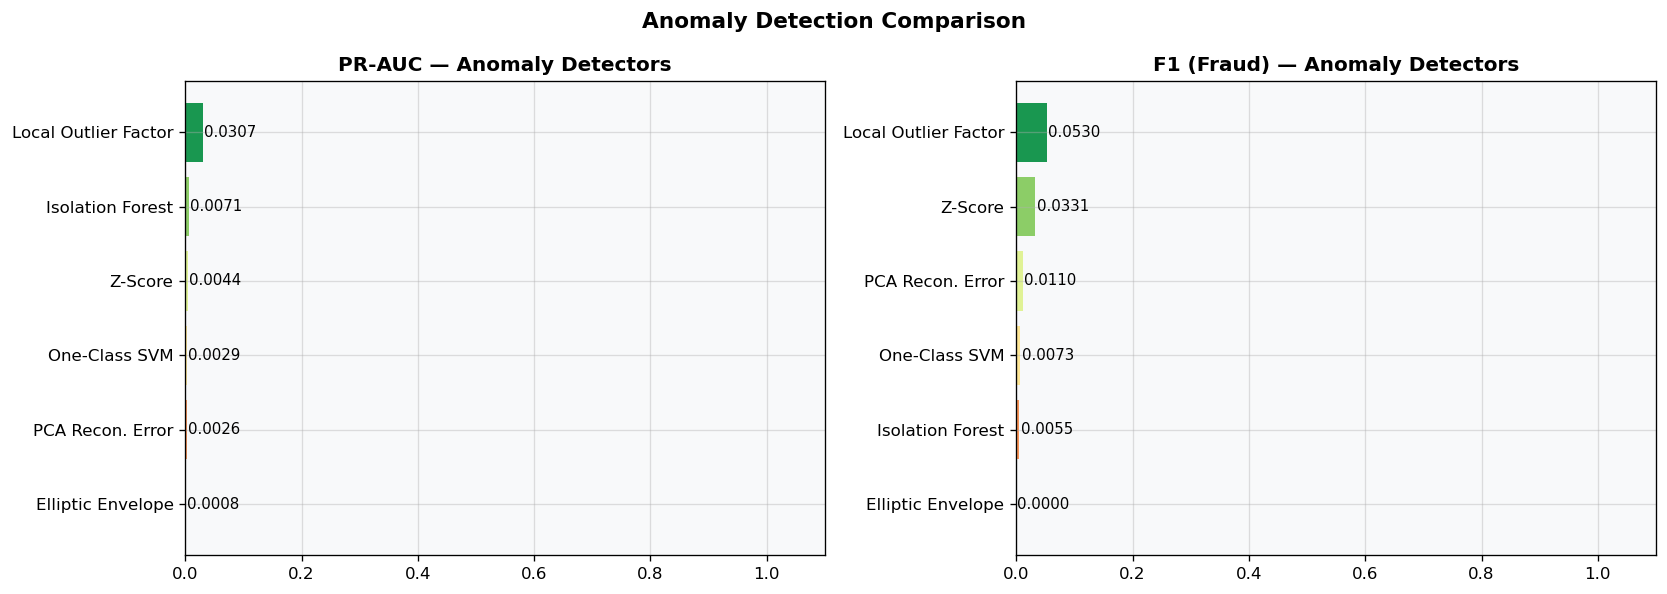

In [11]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Comparison of All Anomaly Detectors
# ══════════════════════════════════════════════════════════
anom_results = {
    'Isolation Forest': {
        'labels': iso_labels, 'scores': iso_scores},
    'Local Outlier Factor': {
        'labels': lof_labels, 'scores': lof_scores},
    'One-Class SVM': {
        'labels': ocsvm_labels, 'scores': ocsvm_scores},
    'Elliptic Envelope': {
        'labels': ee_labels, 'scores': ee_scores},
    'PCA Recon. Error': {
        'labels': pca_labels, 'scores': recon_errors},
    'Z-Score': {
        'labels': z_labels, 'scores': z_scores},
}

anom_table = pd.DataFrame({
    name: {
        'F1 (Fraud)': f1_score(y, r['labels'], zero_division=0),
        'PR-AUC':     average_precision_score(y, r['scores']),
        'ROC-AUC':    roc_auc_score(y, r['scores']),
        'N Flagged':  r['labels'].sum()
    } for name, r in anom_results.items()
}).T.sort_values('PR-AUC', ascending=False)

print('Anomaly Detection Algorithm Comparison:')
print(anom_table.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['PR-AUC', 'F1 (Fraud)']):
    vals = anom_table[col].sort_values()
    colors_a = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(vals)))
    ax.barh(vals.index, vals.values, color=colors_a)
    for i, (idx, val) in enumerate(vals.items()):
        ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_title(f'{col} — Anomaly Detectors', fontweight='bold')

plt.suptitle('Anomaly Detection Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_anom_03_comparison.png', bbox_inches='tight')
plt.show()

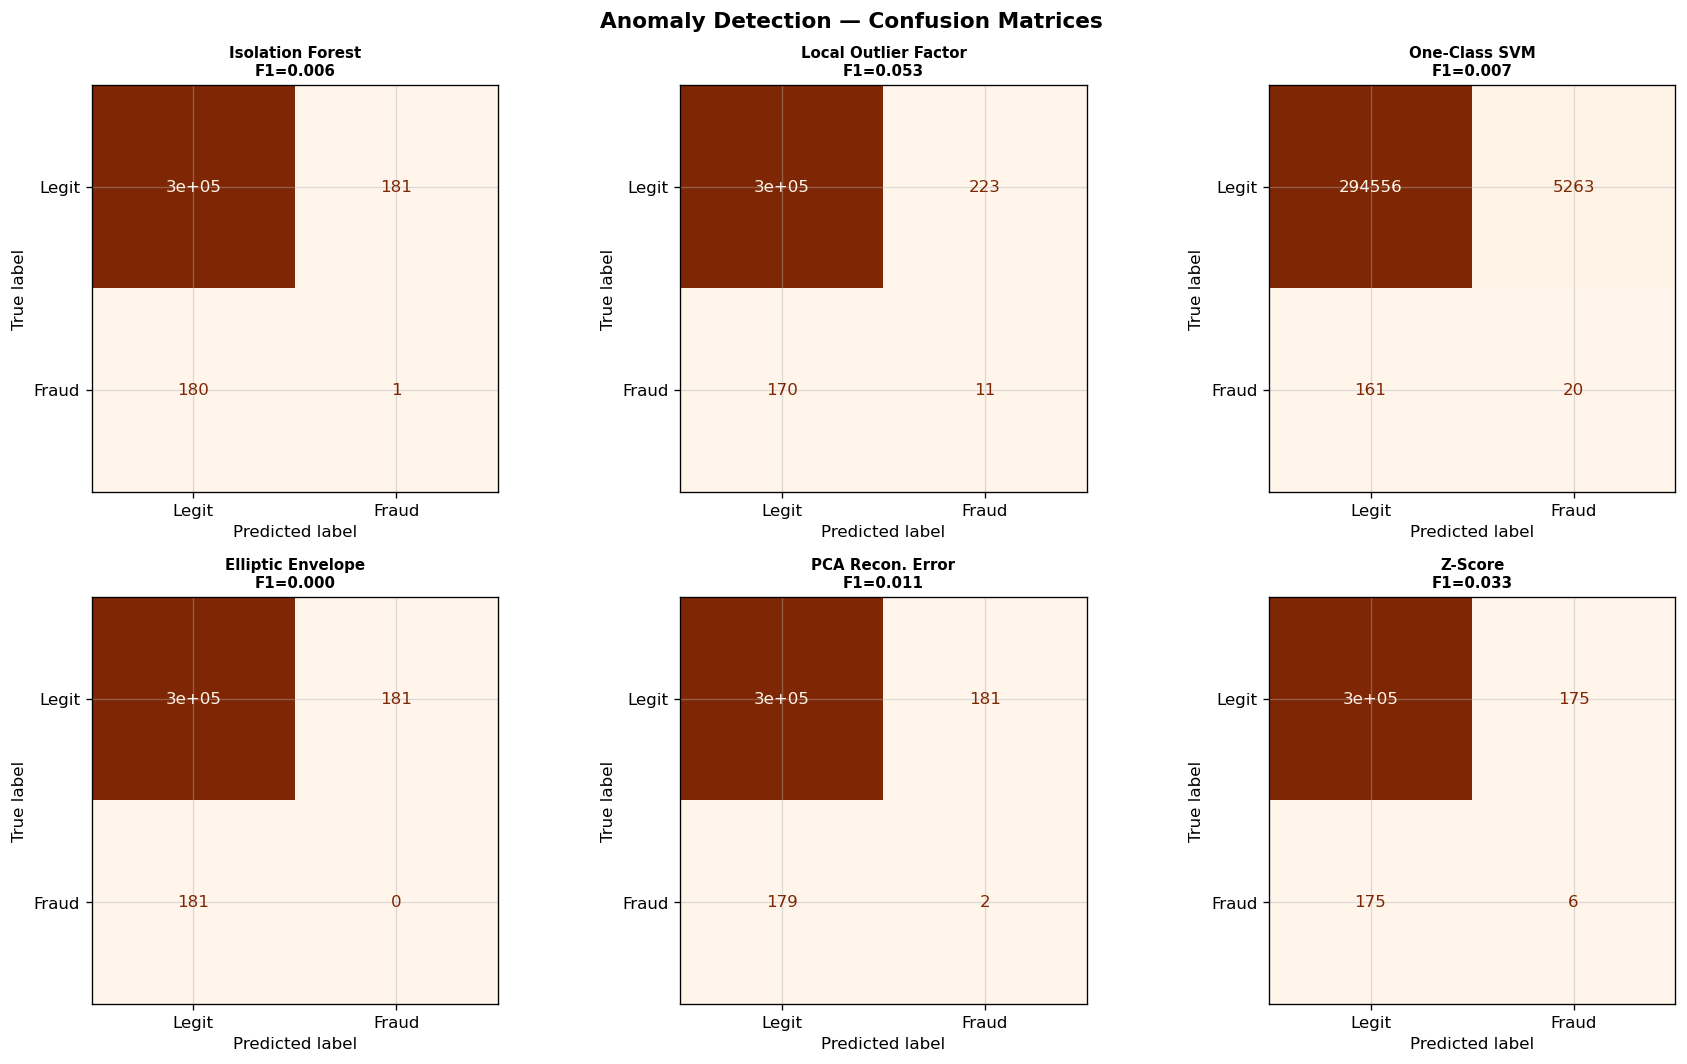

In [12]:
# ══════════════════════════════════════════════════════════
# CELL 11 — Confusion Matrices Side by Side
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, r) in zip(axes.flatten(), anom_results.items()):
    cm = confusion_matrix(y, r['labels'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot(
        ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'{name}\nF1={f1_score(y, r["labels"], zero_division=0):.3f}',
                 fontweight='bold', fontsize=9)

plt.suptitle('Anomaly Detection — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_anom_04_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [13]:
# ══════════════════════════════════════════════════════════
# CELL 12 — Summary & Paradigm Comparison
# ══════════════════════════════════════════════════════════
print('╔' + '═'*68 + '╗')
print('║{:^68}║'.format('ANOMALY DETECTION SUMMARY'))
print('╠' + '═'*68 + '╣')
print('║{:^68}║'.format('Algorithm Performance'))
print('╠' + '═'*68 + '╣')
for name, row in anom_table.iterrows():
    print(f'║  {name:<25} F1={row["F1 (Fraud)"]:.3f}  PR-AUC={row["PR-AUC"]:.3f}  Flagged={int(row["N Flagged"]):>5}  ║')
print('╠' + '═'*68 + '╣')
print('║{:^68}║'.format('When to Use Anomaly Detection vs Classification'))
print('╠' + '═'*68 + '╣')
rows_s = [
    'Use Anomaly Detection when: no fraud labels available',
    'Use Anomaly Detection when: new fraud types expected',
    'Use Classification when: labelled data is abundant',
    'Isolation Forest: fast, scalable, best general choice',
    'PCA Recon. Error: interpretable, good for audit trail',
    'Combine both: anomaly score as FEATURE for classifier',
]
for r in rows_s:
    print(f'║  → {r:<64}║')
print('╚' + '═'*68 + '╝')
print('\n→ Next: lab1_05_clustering.ipynb')

╔════════════════════════════════════════════════════════════════════╗
║                     ANOMALY DETECTION SUMMARY                      ║
╠════════════════════════════════════════════════════════════════════╣
║                       Algorithm Performance                        ║
╠════════════════════════════════════════════════════════════════════╣
║  Local Outlier Factor      F1=0.053  PR-AUC=0.031  Flagged=  234  ║
║  Isolation Forest          F1=0.006  PR-AUC=0.007  Flagged=  182  ║
║  Z-Score                   F1=0.033  PR-AUC=0.004  Flagged=  181  ║
║  One-Class SVM             F1=0.007  PR-AUC=0.003  Flagged= 5283  ║
║  PCA Recon. Error          F1=0.011  PR-AUC=0.003  Flagged=  183  ║
║  Elliptic Envelope         F1=0.000  PR-AUC=0.001  Flagged=  181  ║
╠════════════════════════════════════════════════════════════════════╣
║          When to Use Anomaly Detection vs Classification           ║
╠════════════════════════════════════════════════════════════════════╣
║  → Use Ano

In [14]:
# ══════════════════════════════════════════════════════════
# UNIVERSAL REPORT SUMMARY GENERATOR
# Paste this as the last cell in any notebook to auto-extract metrics
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

print("="*80)
print("📊 AUTOMATED LAB REPORT SUMMARY GENERATOR")
print("="*80)

# Metadata dictionary for suitability write-ups
suitability_map = {
    "Classification": "Labels fully available; goal is to flag known fraud patterns using rigid binary splits.",
    "Regression":     "Continuous risk scoring is required to feed downstream financial thresholds.",
    "Ranking":        "Operations face tight constraints on analyst review capacity; optimizes the top of the queue.",
    "Ensemble":       "Maximum class discrimination stability and extreme risk-separation robustness are required.",
    "Unsupervised":   "Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods.",
    "Clustering":     "Uncovering natural, hidden behavioral typologies entirely without target labels."
}

# --- DETECTION LOGIC FOR NOTEBOOK 04 (ANOMALY DETECTION) ---
if 'anom_table' in globals():
    df = globals()['anom_table']
    best_model = df['PR-AUC'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
    print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
    print(f"| **Anomaly Detection** | {best_model} | {row.get('F1 (Fraud)', row.get('F1-Score (Fraud)', 0)):.4f} | N/A | {row['ROC-AUC']:.4f} (ROC) <br> {row['PR-AUC']:.4f} (PR) | {suitability_map['Unsupervised']} |")

# --- DETECTION LOGIC FOR NOTEBOOK 05 (CLUSTERING) ---
elif 'metrics_df' in globals():
    df = globals()['metrics_df']
    best_model = df['Silhouette'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Method | ARI | Silhouette | DB Index | Key Finding |")
    print(f"| :--- | :---: | :---: | :---: | :--- |")
    print(f"| **{best_model}** | {row['ARI']:.4f} | {row['Silhouette']:.4f} | {row['Davies-Bouldin']:.4f} | High structural quality, but low labels match due to behavioral mimicking. |")

# --- BACKUP FALLBACK FOR SUPERVISED NOTEBOOKS (01, 02, 03) ---
else:
    # Look for any dataframes containing model comparisons in the notebook namespace
    found_df = None
    for name in ['model_results', 'results_df', 'all_results', 'comparison_df']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            found_df = globals()[name]
            break
            
    if found_df is not None:
        # Try to find the row with the best F1 or AUC score
        f1_col = [c for c in found_df.columns if 'f1' in c.lower()]
        auc_col = [c for c in found_df.columns if 'auc' in c.lower() or 'roc' in c.lower()]
        
        target_f1 = f1_col[0] if f1_col else found_df.columns[0]
        best_model = found_df[target_f1].idxmax()
        row = found_df.loc[best_model]
        
        f1_val = f" {row[f1_col[0]]:.4f}" if f1_col else "N/A"
        auc_val = f" {row[auc_col[0]]:.4f}" if auc_col else "N/A"
        recall_val = "Check notebook metrics"
        
        print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
        print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
        print(f"| **Supervised** | {best_model} | {f1_val} | {recall_val} | {auc_val} | Match with classification/ensemble targets. |")
    else:
        print("❌ Could not auto-detect summary tables in memory.")
        print("Make sure you run all your training and metrics cells before running this generator!")
print("="*80)

📊 AUTOMATED LAB REPORT SUMMARY GENERATOR
| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Anomaly Detection** | Local Outlier Factor | 0.0530 | N/A | 0.9291 (ROC) <br> 0.0307 (PR) | Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods. |
